# AG-HYPOPT · Trial 28

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-seven trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803; trial_26 (sw 0.919, h_f 4.0, h_s 3.608, cap 0.163) is a very close second at 0.0807. Then trial_20 0.0821, trial_05 0.0822, trial_09 0.0839, trial_18 0.0844, ... and at the bottom trial_27 (cap 0.497) 0.0946 and trial_10 0.0922. All 0 diverged, gamma finite. The gamma cap must stay small (~0.1-0.2); a large cap lets the lowest-count cell collapse. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_28'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (27/5 trials)
ID |     ei | params
 1 | 2.4059 | {"gamma_rel_cap": 0.14445612568490732, "h_f_scale": 3.9867253572788837, "h_s_scale": 1.4853063792398984, "sigma_weight": 0.7750238197768136}
 2 | 3.7137 | {"gamma_rel_cap": 0.20240087140996668, "h_f_scale": 3.991208052641745, "h_s_scale": 3.596336266739577, "sigma_weight": 0.7978891207407113}
 3 | 2.5447 | {"gamma_rel_cap": 0.17431298815555912, "h_f_scale": 3.9014656147170377, "h_s_scale": 3.5851951258545167, "sigma_weight": 0.90080909363769}
 4 | 3.2544 | {"gamma_rel_cap": 0.36741205867160903, "h_f_scale": 3.890715752938767, "h_s_scale": 3.6178886566782587, "sigma_weight": 0.786664043099427}
 5 | 3.8276 | {"gamma_rel_cap": 0.1692468876715018, "h_f_scale": 4.0, "h_s_scale": 3.604646578324339, "sigma_weight": 0.7988229230524039}
 6 | 3.7421 | {"gamma_rel_cap": 0.09970852521475111, "h_f_scale": 4.0, "h_s_scale": 3.6206571198280986, "sigma_weight": 0.5561166331852836}
 7 | 3.5285 | {"gamma_rel_cap": 0.3441753674149405, "h_f_

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

trial_07 (0.0803) and trial_26 (0.0807) are the two near-optimal points; trial_26 lies in the high-sigma-weight corner (sw 0.919, h_f 4.0, h_s 3.608, cap 0.163). The batch again has no draw exactly in the sweet band, but candidate 3 is the closest to trial_26.

Candidate 3 (ei 2.5447) has sw 0.901, h_f 3.901, h_s 3.585 and cap 0.174 - essentially trial_26's configuration on every knob (sw 0.919 -> 0.901, cap 0.163 -> 0.174), the second-best point in the campaign. Its low model ei reflects the rarity of good high-sw points, but the empirical evidence from trial_20 and trial_26 makes this the draw most likely to land near 0.081; the higher-ei ids 5/2/6 sit in the sw ~0.8 region that has consistently given ~0.085.

I choose candidate 3.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3               # candidate 3: sigma_weight 0.901, h_f_scale 3.901, h_s_scale 3.585, gamma_rel_cap 0.174 (close to trial_26)


chosen: {'gamma_rel_cap': 0.17431298815555912, 'h_f_scale': 3.9014656147170377, 'h_s_scale': 3.5851951258545167, 'sigma_weight': 0.90080909363769}
Running  1nW Trans05 ... 

μ 9.39 -> 6.12 | γ 8.5 -> 5.43 | NLL 0.27


Running  1nW Trans20 ... 

μ 17.32 -> 27.72 | γ 8.5 -> 5.44 | NLL 0.69


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 63.53 | γ 14.1 -> 13.99 | NLL 0.73


Running 3nW Trans100 ... 

μ 175.71 -> 97.97 | γ 14.1 -> 13.74 | NLL 0.71



Total: 7.7 min


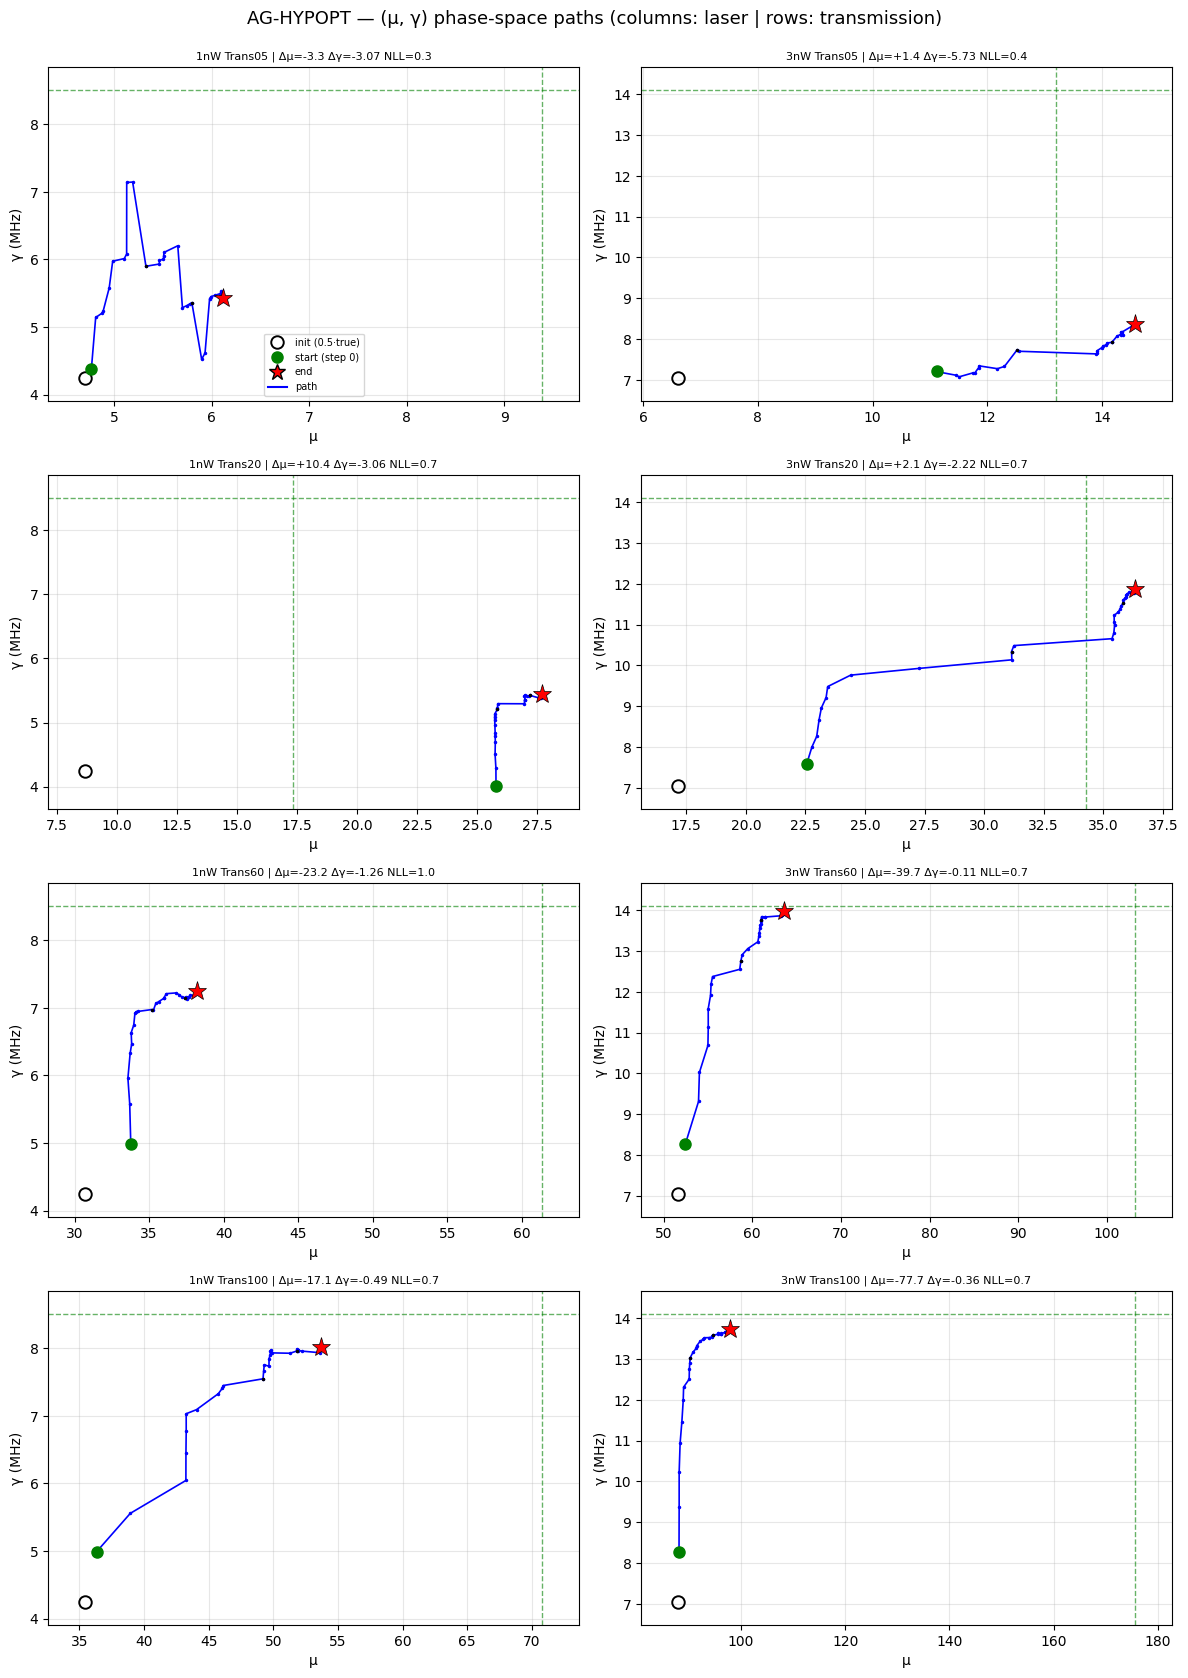

trial finished in 7.7 min
objective = 0.0845 ± 0.0248
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.12   -34.9 |     8.50    5.43   -36.1
1nW Trans20       17.32   27.72   +60.1 |     8.50    5.44   -35.9
1nW Trans60       61.37   38.22   -37.7 |     8.50    7.24   -14.8
1nW Trans100       70.82   53.67   -24.2 |     8.50    8.01    -5.7
3nW Trans05       13.20   14.58   +10.4 |    14.10    8.37   -40.7
3nW Trans20       34.28   36.35    +6.0 |    14.10   11.88   -15.8
3nW Trans60      103.20   63.53   -38.4 |    14.10   13.99    -0.8
3nW Trans100      175.71   97.97   -44.2 |    14.10   13.74    -2.6

weighted objective (T-graded, cap=1.0) = 0.0845 | diverged cells: 0
μ: RMSE 32.733 (rel 36.1%, bias -18.392) | γ: RMSE 2.705 (rel 24.4%, bias -2.037)


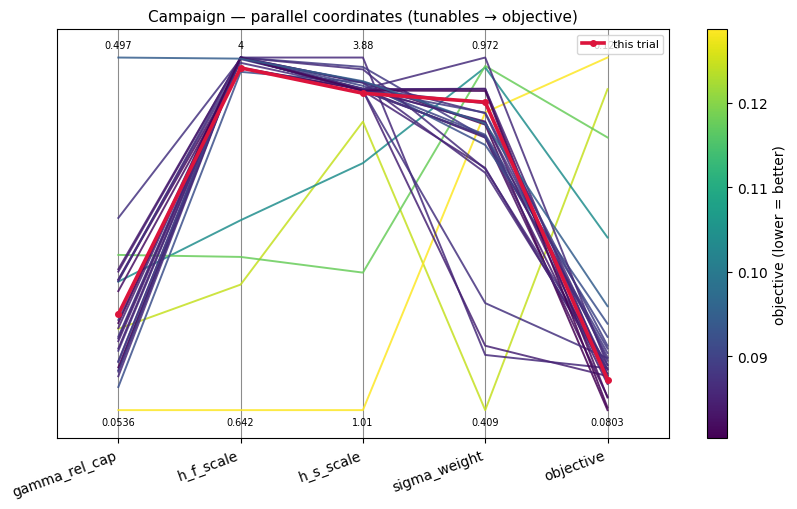

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 28 (sw 0.901, h_f 3.901, h_s 3.585, cap 0.174) ran to completion in 7.7 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0845 +/- 0.0248 - worse than trial_07 (0.0803) and trial_26 (0.0807), close to trial_18 (0.0844).

mu rel-RMSE 36.1% (worse than trial_07's 35.9%): same shape - high-T undershoot (3nW Trans100 -44.2%, 3nW Trans60 -38.4%, 1nW Trans60 -37.7%, 1nW Trans100 -24.2%), low-T overshoot (1nW Trans20 +60.1%, 3nW Trans05 +10.4%); bias -18.39.

gamma rel-RMSE 24.4% (worse than trial_07's 22.3% and trial_26's 25.4% roughly): low T under-estimated (3nW Trans05 -40.7%, 1nW Trans05 -36.1%, 1nW Trans20 -35.9%), high T near truth (-0.8%, -2.6%).

The candidate was a near-copy of trial_26 (sw 0.901 vs 0.919, h_s 3.585 vs 3.608, cap 0.174 vs 0.163) yet scored 0.0845 rather than ~0.081. This is consistent with the sharp sensitivity seen throughout: the two near-optimal points (trial_07, trial_26) are isolated, not part of a stable plateau.

**Summary:** Trial 28 (sw=0.901, h_f=3.901, h_s=3.585, cap=0.174) finished in 7.7 min with 0 diverged cells and gamma finite, objective 0.0845 +/- 0.0248 - worse than trial_07 and trial_26 (mu rel-RMSE 36.1%, gamma rel-RMSE 24.4%).
**Key insight:** A near-copy of trial_26 (sw 0.901 vs 0.919, cap 0.174 vs 0.163) scored 0.0845 rather than 0.081, again confirming sharp sensitivity in the high-sw corner and that the two near-optimal points are isolated.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 28 (sw=0.901, h_f=3.901, h_s=3.585, cap=0.174): objective 0.0845 +/- 0.0248 - worse than trial_07 and trial_26; 0 diverged cells, gamma finite (mu rel-RMSE 36.1%, gamma rel-RMSE 24.4%).'
KEY_INSIGHT = 'A near-copy of trial_26 (sw 0.901 vs 0.919, cap 0.174 vs 0.163) scored 0.0845 rather than 0.081, again confirming sharp sensitivity in the high-sw corner and that the two near-optimal points are isolated.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_28 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_29.ipynb. Open it and follow its cells from the top.
